### Weather Australia

In [1]:
import numpy as np 
import pandas as pd
from datetime import datetime
from pandas import DataFrame

pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 500)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("Dataset/cleaned_weatherAUS.csv", parse_dates=["Date"])
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71382 entries, 0 to 71381
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           71382 non-null  datetime64[ns]
 1   Location       71382 non-null  object        
 2   MinTemp        70765 non-null  float64       
 3   MaxTemp        70793 non-null  float64       
 4   Rainfall       70471 non-null  float64       
 5   Evaporation    71382 non-null  float64       
 6   Sunshine       71382 non-null  float64       
 7   WindGustDir    67031 non-null  object        
 8   WindGustSpeed  67054 non-null  float64       
 9   WindDir9am     68765 non-null  object        
 10  WindDir3pm     70664 non-null  object        
 11  WindSpeed9am   71167 non-null  float64       
 12  WindSpeed3pm   70950 non-null  float64       
 13  Humidity9am    70469 non-null  float64       
 14  Humidity3pm    70293 non-null  float64       
 15  Pressure9am    7072

In [3]:
print(dataset)

            Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine WindGustDir  WindGustSpeed WindDir9am WindDir3pm  WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm RainToday RainTomorrow
0     2009-01-01    Cobar     17.9     35.2       0.0         12.0      12.3         SSW           48.0        ENE         SW           6.0          20.0         20.0         13.0       1006.3       1004.4       2.0       5.0     26.6     33.4        No           No
1     2009-01-02    Cobar     18.4     28.9       0.0         14.8      13.0           S           37.0        SSE        SSE          19.0          19.0         30.0          8.0       1012.9       1012.1       1.0       1.0     20.3     27.0        No           No
2     2009-01-03    Cobar     15.5     34.1       0.0         12.6      13.3          SE           30.0        NaN          N           NaN           7.0          NaN          7.0          NaN       

In [4]:
dataset.notnull()
dataset.ffill(inplace=True)

In [5]:
dataset.isna().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

In [6]:
x = ["Yes", "No"]
y = [
(dataset["RainTomorrow"] == "No").sum(),
(dataset["RainTomorrow"] == "Yes").sum(),
]
bar_colors = ['tab:red', 'tab:blue']

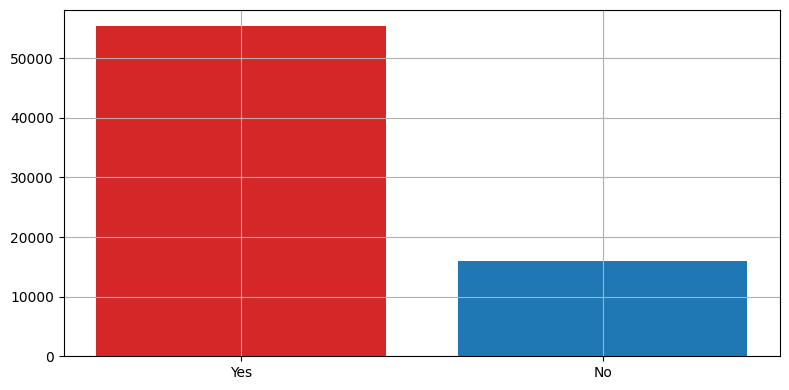

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x, y, color=bar_colors)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.grid(True)
# ax.legend(title='')

plt.tight_layout()
plt.show()

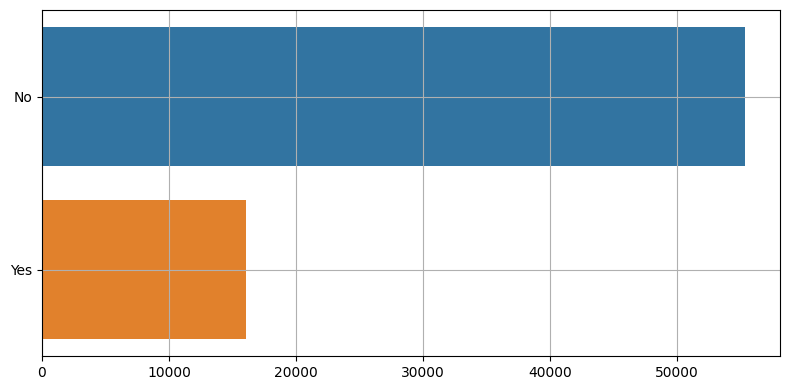

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.countplot(dataset, y="RainTomorrow", hue="RainTomorrow")

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.grid(True)
# ax.legend(title='')

plt.tight_layout()
plt.show()

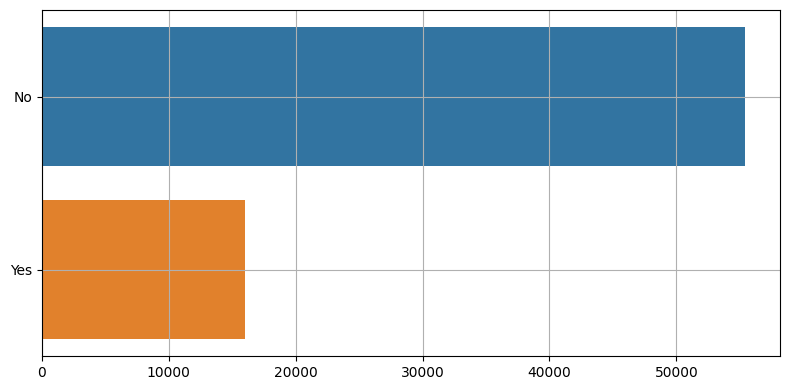

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.countplot(dataset, y="RainToday", hue="RainToday")

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.grid(True)
# ax.legend(title='')

plt.tight_layout()
plt.show()

<Axes: >

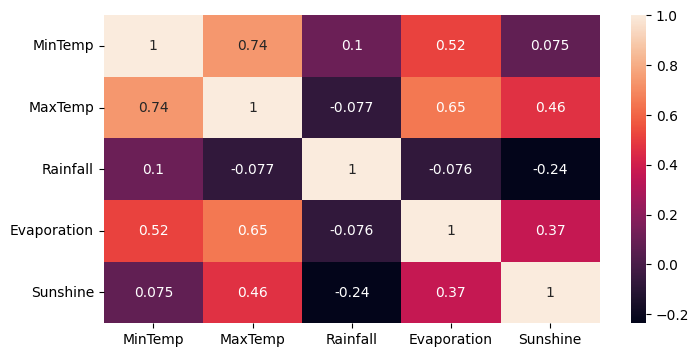

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

df_heatmap = dataset[["MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine"]].corr()
sns.heatmap(data=df_heatmap, annot=True)

In [55]:
df_heatmap = dataset[["MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine"]].corr()
df_heatmap

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine
MinTemp,1.000000,0.738923,0.103336,0.516272,0.075352
MaxTemp,0.738923,1.000000,-0.076842,0.649262,0.463906
Rainfall,0.103336,-0.076842,1.000000,-0.075661,-0.236443
Evaporation,0.516272,0.649262,-0.075661,1.000000,0.365602
Sunshine,0.075352,0.463906,-0.236443,0.365602,1.000000


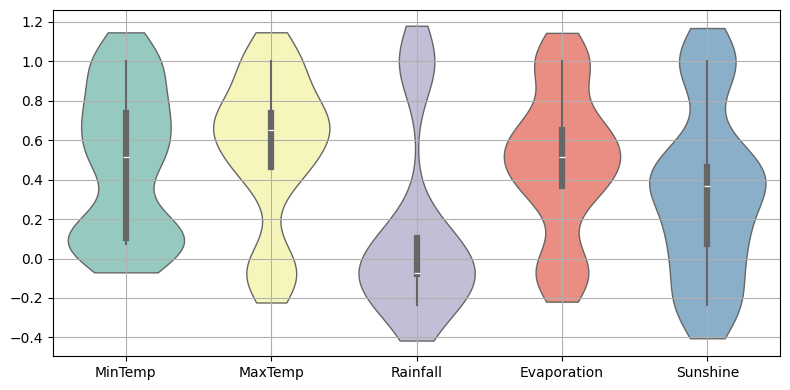

In [57]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.violinplot(data=df_heatmap, bw_adjust=.5, cut=1, linewidth=1, palette="Set3")

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.grid(True)
# ax.legend(title='', ncol=3)

plt.tight_layout()
plt.show()

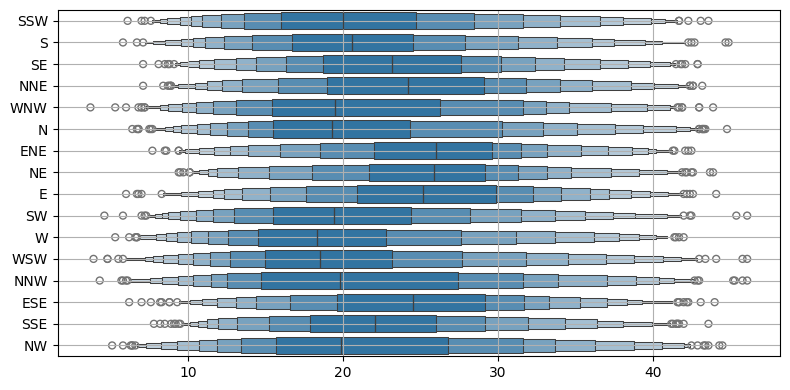

In [64]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.boxenplot(data=dataset, x="Temp3pm", y="WindGustDir", width_method="linear")

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.grid(True)
# ax.legend(title='', ncol=3)

plt.tight_layout()
plt.show()

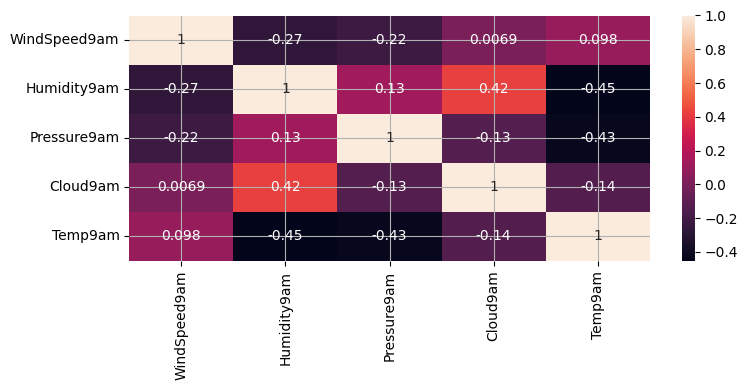

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

df_heatmap = dataset[["WindSpeed9am", "Humidity9am", "Pressure9am", "Cloud9am", "Temp9am"]].corr()
sns.heatmap(data=df_heatmap, annot=True)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.grid(True)
# ax.legend(title='', ncol=3)

plt.tight_layout()
plt.show()

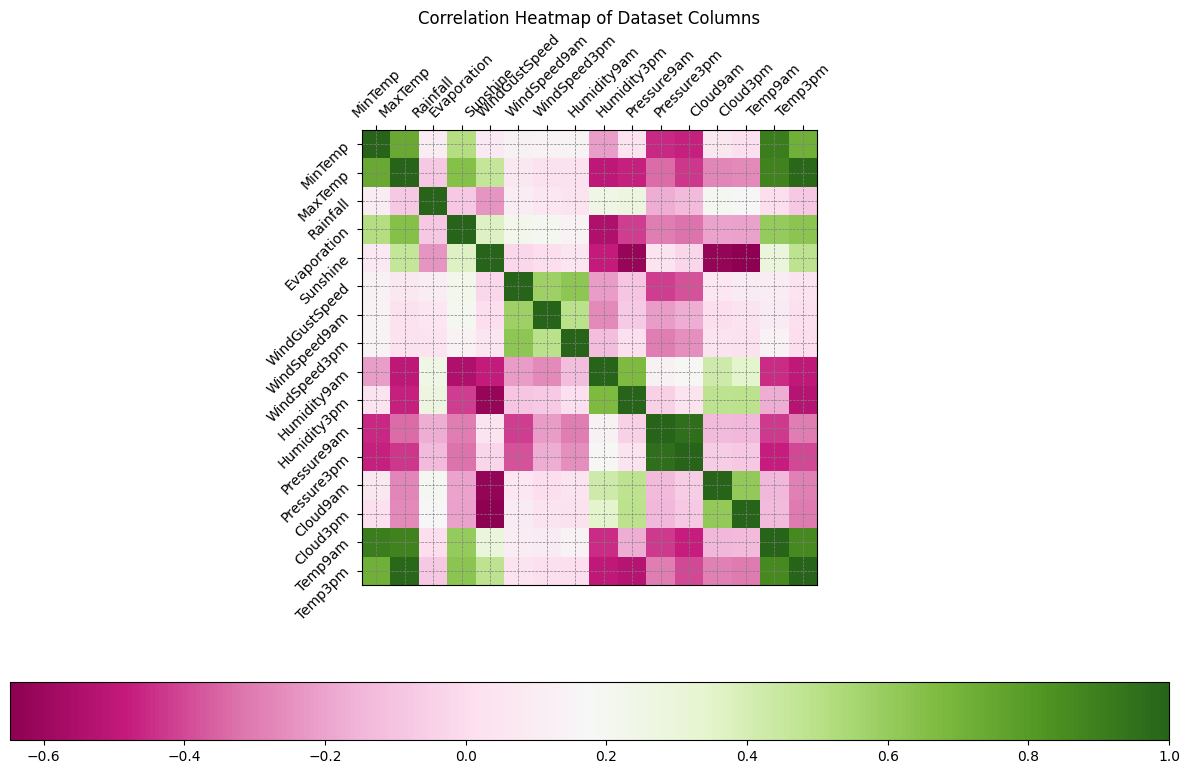

In [12]:
# Create the heatmap using Seaborn (which builds on Matplotlib)
# plt.figure(figsize=(12, 8))
fig, ax = plt.subplots(figsize= (12, 8))

df_heatmap = dataset[["MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine", "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm", 
                      "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm", "Cloud9am", "Cloud3pm", "Temp9am", "Temp3pm"]].corr()
df = pd.DataFrame(df_heatmap)

ax.set_xticks(np.arange(len(df.columns)))
ax.set_xticklabels(df.columns)
ax.set_yticks(np.arange(len(df.index)))
ax.set_yticklabels(df.index)
ax.tick_params(top=True, bottom=False,labeltop=True, rotation=45, labelbottom=False)
# plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

img = plt.imshow(df_heatmap, cmap='PiYG')
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.colorbar(img, orientation='horizontal')
plt.title('Correlation Heatmap of Dataset Columns')
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [13]:
dataset[["WindGustDir", "RainTomorrow"]]

,WindGustDir,RainTomorrow
0,SSW,No
1,S,No
2,SE,No
3,NNE,No
4,WNW,No
...,...,...
71377,ENE,No
71378,E,No
71379,E,No
71380,ESE,No


In [14]:
wgd = dataset.groupby("WindGustDir")["RainTomorrow"].count()
wgd = wgd.sort_values(ascending=False)

df_wgd = pd.DataFrame(wgd).reset_index()
df_wgd

,WindGustDir,RainTomorrow
0,N,7778
1,SE,5652
2,SW,5038
3,W,5030
4,E,4986
5,SSW,4724
6,WSW,4629
7,ENE,4435
8,S,4383
9,SSE,4013


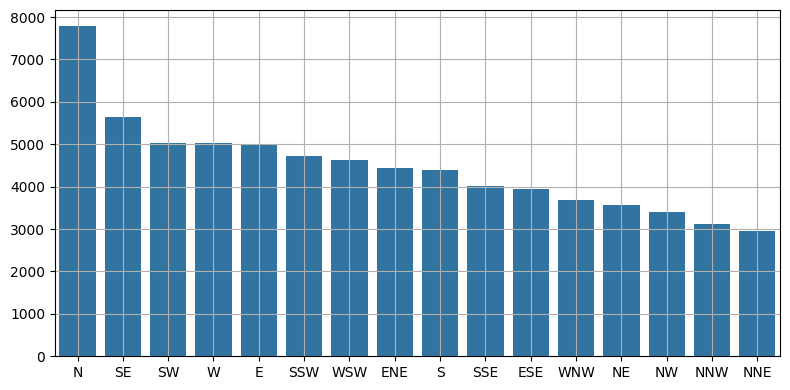

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(df_wgd, x="WindGustDir", y="RainTomorrow")

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.grid(True)
# ax.legend(title='', ncol=1)

plt.tight_layout()
plt.show()

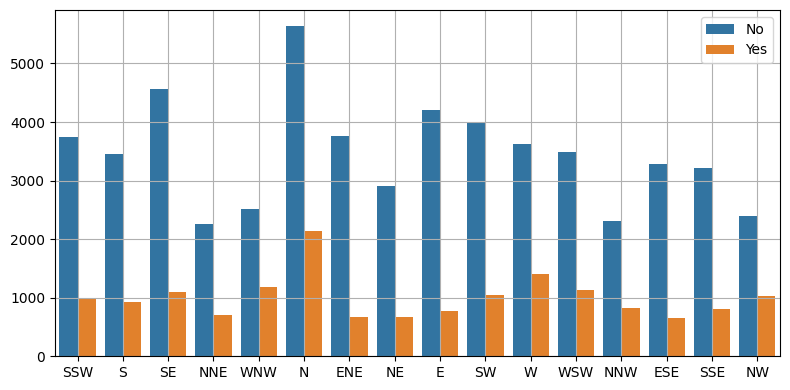

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.countplot(dataset, x="WindGustDir", hue="RainTomorrow")

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.grid(True)
ax.legend(title='', ncol=1)

plt.tight_layout()
plt.show()

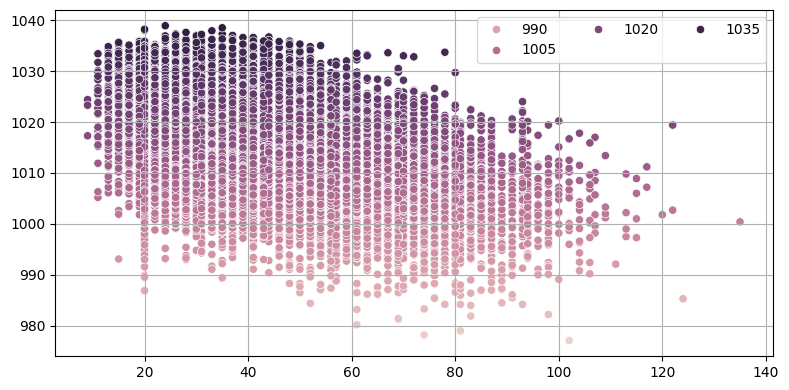

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.scatterplot(data=dataset, x="WindGustSpeed", y="Pressure3pm", hue="Pressure3pm")

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.grid(True)
ax.legend(title='', ncol=3)

plt.tight_layout()
plt.show()

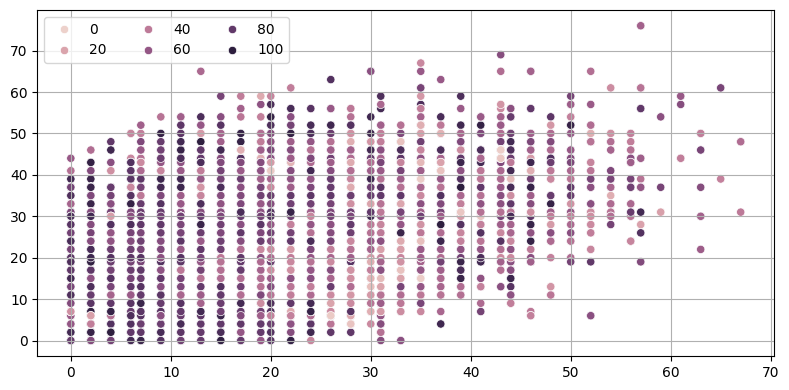

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.scatterplot(data=dataset, x="WindSpeed9am", y="WindSpeed9am", hue="Humidity9am")

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.grid(True)
ax.legend(title='', ncol=3)

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


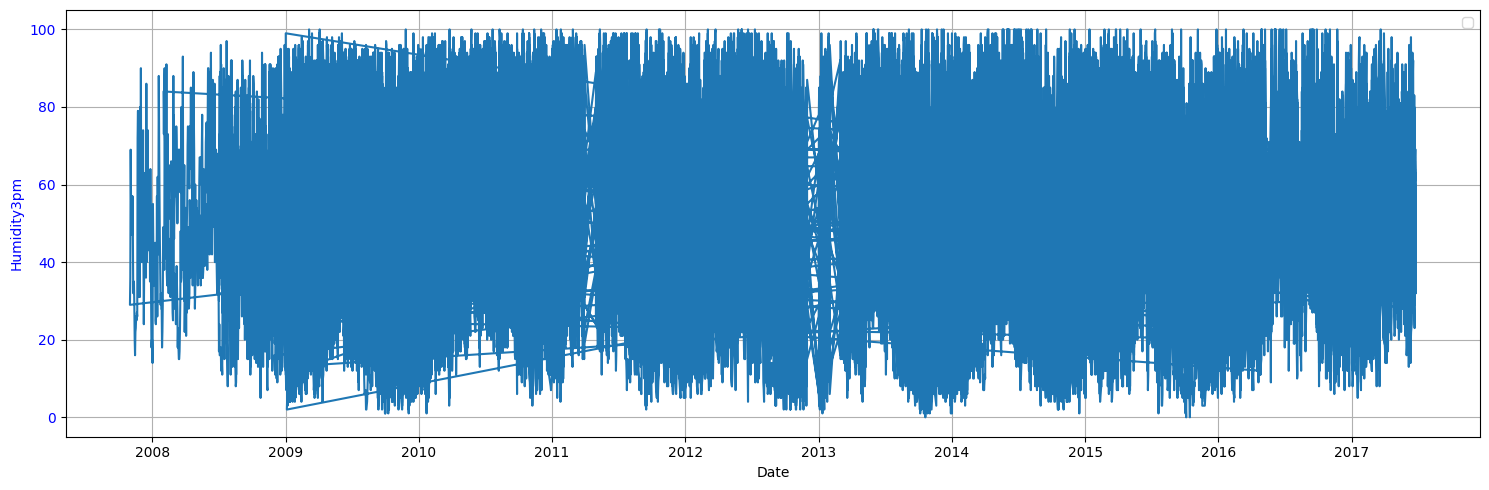

In [18]:
fig, ax = plt.subplots(figsize= (15, 5))

ax.plot(dataset['Date'], dataset['Humidity3pm'])
ax.set_title('')
ax.set_xlabel('Date')
ax.set_ylabel('Humidity3pm', color='blue')
ax.grid(True)
ax.tick_params(axis='y', labelcolor='blue')
ax.legend(title='', ncol=3)

plt.tight_layout()
plt.show()

In [19]:
# fig, ax = plt.subplots(figsize= (15, 5))

# sns.lineplot(data=dataset, x="Date", y="Humidity3pm")

In [20]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71382 entries, 0 to 71381
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           71382 non-null  datetime64[ns]
 1   Location       71382 non-null  object        
 2   MinTemp        71382 non-null  float64       
 3   MaxTemp        71382 non-null  float64       
 4   Rainfall       71382 non-null  float64       
 5   Evaporation    71382 non-null  float64       
 6   Sunshine       71382 non-null  float64       
 7   WindGustDir    71382 non-null  object        
 8   WindGustSpeed  71382 non-null  float64       
 9   WindDir9am     71382 non-null  object        
 10  WindDir3pm     71382 non-null  object        
 11  WindSpeed9am   71382 non-null  float64       
 12  WindSpeed3pm   71382 non-null  float64       
 13  Humidity9am    71382 non-null  float64       
 14  Humidity3pm    71382 non-null  float64       
 15  Pressure9am    7138

In [21]:
df_location = dataset.groupby("Location")[["MinTemp", "MaxTemp", "Rainfall"]].mean().sort_values(by='Rainfall', ascending=False).reset_index().head(5)
df_location = np.round(df_location, decimals=2)
df_location

,Location,MinTemp,MaxTemp,Rainfall
0,Cairns,21.12,29.55,4.58
1,Darwin,23.19,32.56,4.09
2,CoffsHarbour,14.39,23.73,3.83
3,Brisbane,16.39,26.43,2.90
4,Sydney,14.88,23.03,2.82


In [22]:
df_melt = pd.melt(df_location, id_vars=['Location'], value_vars=['MinTemp', 'MaxTemp', 'Rainfall'])
df_melt

,Location,variable,value
0,Cairns,MinTemp,21.12
1,Darwin,MinTemp,23.19
2,CoffsHarbour,MinTemp,14.39
3,Brisbane,MinTemp,16.39
4,Sydney,MinTemp,14.88
5,Cairns,MaxTemp,29.55
6,Darwin,MaxTemp,32.56
7,CoffsHarbour,MaxTemp,23.73
8,Brisbane,MaxTemp,26.43
9,Sydney,MaxTemp,23.03


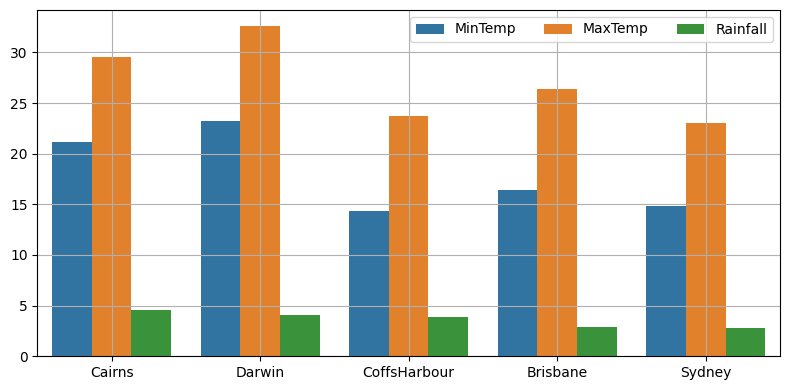

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(data=df_melt, x="Location", y="value", hue="variable")

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.grid(True)
ax.legend(title='', ncol=3)

plt.tight_layout()
plt.show()

In [24]:
df_location2 = dataset.groupby("Location")[["WindSpeed9am", "Humidity9am", "Cloud9am"]].mean().sort_values(by='Cloud9am', ascending=False).reset_index().head(5)
df_location2 = np.round(df_location2, decimals=2)
df_location2


,Location,WindSpeed9am,Humidity9am,Cloud9am
0,Adelaide,10.63,58.84,7.00
1,Dartmoor,11.07,85.85,7.00
2,Portland,16.28,78.78,6.26
3,Hobart,16.30,65.58,5.62
4,MountGambier,17.53,74.68,5.36


In [25]:
df_melt2 = pd.melt(df_location2, id_vars=['Location'], value_vars=['WindSpeed9am', 'Humidity9am', 'Cloud9am'])
df_melt2

,Location,variable,value
0,Adelaide,WindSpeed9am,10.63
1,Dartmoor,WindSpeed9am,11.07
2,Portland,WindSpeed9am,16.28
3,Hobart,WindSpeed9am,16.30
4,MountGambier,WindSpeed9am,17.53
5,Adelaide,Humidity9am,58.84
6,Dartmoor,Humidity9am,85.85
7,Portland,Humidity9am,78.78
8,Hobart,Humidity9am,65.58
9,MountGambier,Humidity9am,74.68


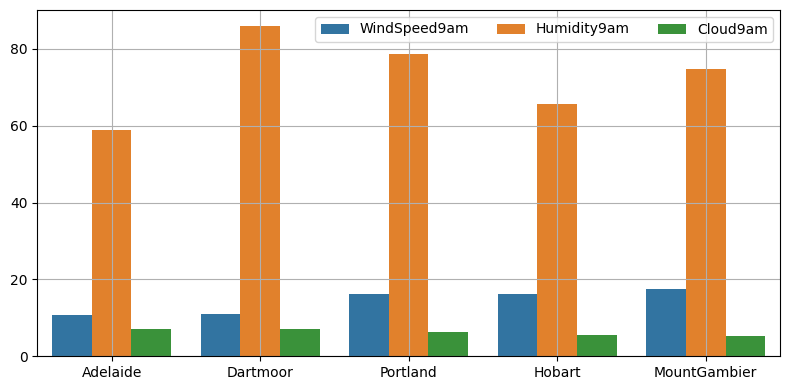

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(data=df_melt2, x="Location", y="value", hue="variable")

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('')
ax.grid(True)
ax.legend(title='', ncol=3)

plt.tight_layout()
plt.show()